# Global Sensitivity B — n_prior_periods Diagnostics

Train-CV diagnostics only. Test·tuning·threshold 변경은 사용하지 않는다.


## 1. 입력과 26 Feature 계약


In [5]:
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT=Path(os.environ.get("KHUDA_PROJECT_ROOT",Path.cwd())).resolve()
while not (ROOT/"code").is_dir():
    if ROOT.parent==ROOT: raise RuntimeError("저장소 안에서 실행하세요.")
    ROOT=ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
if "code" in sys.modules and not hasattr(sys.modules["code"],"__path__"): del sys.modules["code"]
from code.evaluation.evaluate import calculate_binary_metrics
from code.evaluation.sensitivity_diagnostics import cv_permutation_importance, normalize_oof_columns, paired_sampid_bootstrap_f1, subgroup_oof_metrics
from code.model.locked_sensitivity import load_stage_3_5_locked_params
from code.pipeline.audit import attach_person_period_column, calculate_train_sample_weight, load_selected_feature_names
from code.pipeline.saved_results import load_saved_global_train
RESULT_ROOT=ROOT/"data"/"result"/"baseline_42features"; STAGE35=RESULT_ROOT/"modeling"/"stage_3_5"
DATASET=RESULT_ROOT/"datasets"/"global_dataset.parquet"; SPLIT=RESULT_ROOT/"splits"/"split_ids.csv"; FEATURES=ROOT/"code"/"config"/"features.yaml"; MODELS=ROOT/"code"/"config"/"model_config.yaml"
SELECTED=RESULT_ROOT/"modeling"/"stage_3"/"selected_features.csv"; PARAMS=STAGE35/"final_refined_params.json"; A_SUMMARY=STAGE35/"final_tuning_summary.csv"; A_OOF={m:STAGE35/f"refined_{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}
PERSON=RESULT_ROOT/"datasets"/"person_period.parquet"; LOCK=RESULT_ROOT/"modeling"/"sensitivity_n_prior_periods"; TUNE=LOCK/"tuning"; OUT=LOCK/"diagnostics"
LOCK_SUMMARY=LOCK/"locked_model_summary.csv"; LOCK_OOF={m:LOCK/f"locked_{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}; TUNE_OOF={m:TUNE/f"{m}_oof_predictions.parquet" for m in ("logistic_regression","xgboost")}
required=[DATASET,SPLIT,PERSON,FEATURES,MODELS,SELECTED,PARAMS,A_SUMMARY,*A_OOF.values(),LOCK_SUMMARY,*LOCK_OOF.values(),TUNE/"tuning_summary.csv",TUNE/"best_params.json",*TUNE_OOF.values()]
missing=[str(x) for x in required if not x.exists()]
if missing: raise FileNotFoundError("필요한 Train artifact가 없습니다:\n"+"\n".join(missing))
base=load_saved_global_train(DATASET,SPLIT,FEATURES); selected=load_selected_feature_names(SELECTED); frame=attach_person_period_column(base.to_frame(),PERSON,"n_prior_periods")
assert len(selected)==25 and len(selected)+1==26 and "n_prior_periods" in frame


## 2. n_prior_periods 분포와 subgroup OOF


In [6]:
def oof(path): return normalize_oof_columns(pd.read_parquet(path))
def rows(strategy, summary, paths, status, stage=None):
    s=pd.read_csv(summary)
    if stage is not None: s=s.loc[s.stage.eq(stage)]
    s=s.set_index("model"); result=[]
    for model,path in paths.items():
        frame=oof(path); metric=calculate_binary_metrics(frame.y_true,frame.y_probability)
        result.append({"strategy":strategy,"model":model,"feature_count":int(s.loc[model,"feature_count"]),"parameter_status":status,"cv_f1_mean":s.loc[model,"cv_f1_mean"],"cv_f1_std":s.loc[model,"cv_f1_std"],"oof_accuracy":metric["accuracy"],"oof_precision":metric["precision"],"oof_recall":metric["recall"],"oof_f1":metric["f1"],"oof_roc_auc":metric["roc_auc"],"oof_average_precision":metric["average_precision"],"predicted_positive_rate":frame.y_predicted.mean()})
    return pd.DataFrame(result)
def paired(labels, frames):
    out=[]
    for label,left,right in labels:
        row=paired_sampid_bootstrap_f1(frames[left],frames[right]); row.insert(0,"comparison",label); out.append(row)
    return pd.concat(out,ignore_index=True)
distribution=(frame.groupby("n_prior_periods").agg(rows=("SAMPID","size"),unique_SAMPID=("SAMPID","nunique"),positive_count=("employment_transition","sum"),positive_rate=("employment_transition","mean")).reset_index())
distribution["ratio"]=distribution.rows/distribution.rows.sum(); display(distribution)
subgroups=[]
for model,path in TUNE_OOF.items():
    value=subgroup_oof_metrics(oof(path),frame.n_prior_periods,group_name="n_prior_periods"); value.insert(0,"model",model); value.insert(0,"strategy","B tuned"); subgroups.append(value)
prior_group_metrics=pd.concat(subgroups,ignore_index=True); display(prior_group_metrics)


,n_prior_periods,rows,unique_SAMPID,positive_count,positive_rate,ratio
0,0,5737,5737,1507,0.262681,0.48109
1,1,3842,3842,1007,0.262103,0.32218
2,2,2346,2346,602,0.256607,0.19673


,strategy,model,n_prior_periods,rows,unique_SAMPID,positive_count,positive_rate,predicted_positive_rate,accuracy,precision,recall,f1,roc_auc,average_precision,confusion_matrix
0,B tuned,logistic_regression,0,5737,5737,1507,0.262681,0.362036,0.701586,0.450650,0.621102,0.522321,0.732229,0.489326,"[[3089, 1141], [571, 936]]"
1,B tuned,logistic_regression,1,3842,3842,1007,0.262103,0.372723,0.667621,0.405726,0.576961,0.476425,0.688921,0.414043,"[[1984, 851], [426, 581]]"
2,B tuned,logistic_regression,2,2346,2346,602,0.256607,0.380648,0.661125,0.391937,0.581395,0.468227,0.675453,0.388482,"[[1201, 543], [252, 350]]"
3,B tuned,xgboost,0,5737,5737,1507,0.262681,0.397420,0.692697,0.443860,0.671533,0.534460,0.740792,0.495846,"[[2962, 1268], [495, 1012]]"
4,B tuned,xgboost,1,3842,3842,1007,0.262103,0.421655,0.655648,0.402469,0.647468,0.496384,0.696056,0.423517,"[[1867, 968], [355, 652]]"
5,B tuned,xgboost,2,2346,2346,602,0.256607,0.421995,0.651321,0.390909,0.642857,0.486181,0.687167,0.391113,"[[1141, 603], [215, 387]]"


## 3. B tuned validation-fold Permutation Importance


In [7]:
best=json.loads((TUNE/"best_params.json").read_text())
X=frame.loc[:,[*selected,"n_prior_periods"]].reset_index(drop=True)
# 각 fold에서만 재학습하며 Test는 사용하지 않는다.
lr_pi=cv_permutation_importance(X,base.y,base.groups,model_name="logistic_regression",params=best["logistic_regression"],feature_config=FEATURES,model_config=MODELS)
xgb_pi=cv_permutation_importance(X,base.y,base.groups,model_name="xgboost",params=best["xgboost"],feature_config=FEATURES,model_config=MODELS)
display(lr_pi.query("feature == 'n_prior_periods'")); display(xgb_pi.query("feature == 'n_prior_periods'"))


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

,feature,importance_mean,importance_std,positive_repeat_count,positive_fold_count,rank
14,n_prior_periods,0.022491,0.009175,100,5,3


,feature,importance_mean,importance_std,positive_repeat_count,positive_fold_count,rank
14,n_prior_periods,0.009811,0.005551,98,5,6


## 4. A / B locked / B tuned 안정성 비교


In [8]:
def oof(path): return normalize_oof_columns(pd.read_parquet(path))
def rows(strategy, summary, paths, status, stage=None):
    s=pd.read_csv(summary)
    if stage is not None: s=s.loc[s.stage.eq(stage)]
    s=s.set_index("model"); result=[]
    for model,path in paths.items():
        frame=oof(path); metric=calculate_binary_metrics(frame.y_true,frame.y_probability)
        result.append({"strategy":strategy,"model":model,"feature_count":int(s.loc[model,"feature_count"]),"parameter_status":status,"cv_f1_mean":s.loc[model,"cv_f1_mean"],"cv_f1_std":s.loc[model,"cv_f1_std"],"oof_accuracy":metric["accuracy"],"oof_precision":metric["precision"],"oof_recall":metric["recall"],"oof_f1":metric["f1"],"oof_roc_auc":metric["roc_auc"],"oof_average_precision":metric["average_precision"],"predicted_positive_rate":frame.y_predicted.mean()})
    return pd.DataFrame(result)
def paired(labels, frames):
    out=[]
    for label,left,right in labels:
        row=paired_sampid_bootstrap_f1(frames[left],frames[right]); row.insert(0,"comparison",label); out.append(row)
    return pd.concat(out,ignore_index=True)
tuned_summary=pd.read_csv(TUNE/"tuning_summary.csv"); tuned_summary["parameter_status"]="tuned"; tuned_summary["strategy"]="B tuned"
a=rows("A Baseline",A_SUMMARY,A_OOF,"locked",stage="stage_3_5"); locked=rows("B locked",LOCK_SUMMARY,LOCK_OOF,"locked"); tuned=tuned_summary
comparison=pd.concat([a,locked,tuned],ignore_index=True); base_f1=comparison.query("strategy=='A Baseline'").set_index("model").oof_f1; locked_f1=comparison.query("strategy=='B locked'").set_index("model").oof_f1
comparison["delta_oof_f1_vs_A"]=comparison.apply(lambda r:r.oof_f1-base_f1[r.model],axis=1); comparison["locked_to_tuned_delta_f1"]=comparison.apply(lambda r:r.oof_f1-locked_f1[r.model],axis=1); display(comparison)
frames={"A "+m:oof(A_OOF[m]) for m in A_OOF}|{"B locked "+m:oof(LOCK_OOF[m]) for m in LOCK_OOF}|{"B tuned "+m:oof(TUNE_OOF[m]) for m in TUNE_OOF}
bootstrap=pd.concat([paired([( "B locked - A", "B locked "+m,"A "+m),("B tuned - A","B tuned "+m,"A "+m),("B tuned - B locked","B tuned "+m,"B locked "+m)],frames).assign(model=m) for m in ("logistic_regression","xgboost")],ignore_index=True); display(bootstrap)


,strategy,model,feature_count,parameter_status,cv_f1_mean,cv_f1_std,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_cv_f1,best_params,delta_oof_f1_vs_A,locked_to_tuned_delta_f1
0,A Baseline,logistic_regression,25,locked,0.493122,0.022909,0.681342,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,NaN,NaN,0.000000,-0.002365
1,A Baseline,xgboost,25,locked,0.507894,0.016047,0.667002,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,NaN,NaN,0.000000,0.000191
2,B locked,logistic_regression,26,locked,0.495286,0.020928,0.680922,0.422076,0.598845,0.495157,0.707709,0.446198,0.370734,NaN,NaN,0.002365,0.000000
3,B locked,xgboost,26,locked,0.507617,0.018885,0.669350,0.415492,0.652439,0.507679,0.717372,0.456826,0.410314,NaN,NaN,-0.000191,0.000000
4,B tuned,logistic_regression,26,tuned,0.496791,0.019818,0.682683,0.424125,0.599166,0.496675,0.708136,0.445673,0.369140,0.496791,"{'C': 0.15, 'class_weight': 'balanced', 'penal...",0.003882,0.001517
5,B tuned,xgboost,26,tuned,0.512352,0.016850,0.672621,0.419427,0.658216,0.512366,0.717252,0.454836,0.410063,0.512352,{'scale_pos_weight': 'train_negative_positive_...,0.004496,0.004687


,comparison,point_delta_f1,bootstrap_mean_delta,ci_lower,ci_upper,bootstrap_repeats,model
0,B locked - A,0.002365,0.002383,-0.003118,0.007560,1000,logistic_regression
1,B tuned - A,0.003882,0.003918,-0.001553,0.009232,1000,logistic_regression
2,B tuned - B locked,0.001517,0.001535,-0.000500,0.003607,1000,logistic_regression
3,B locked - A,-0.000191,-0.000098,-0.005523,0.005298,1000,xgboost
4,B tuned - A,0.004496,0.004561,-0.001299,0.010628,1000,xgboost
5,B tuned - B locked,0.004687,0.004660,0.000002,0.009079,1000,xgboost


## 5. 저장·그래프·최종 진단 표


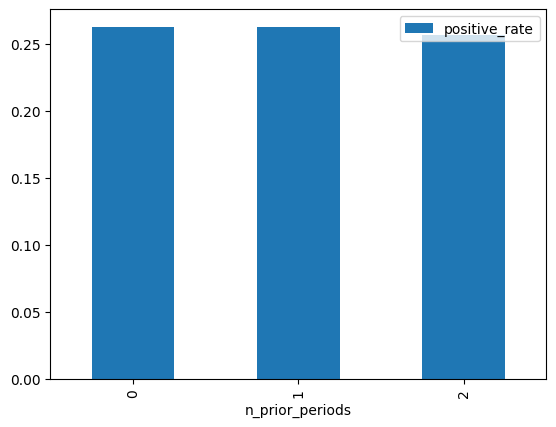

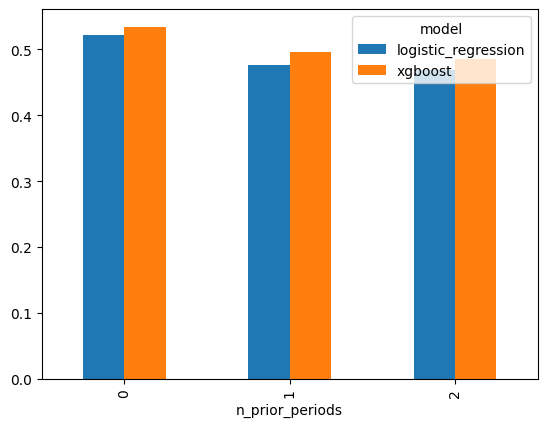

,strategy,model,feature_count,parameter_status,cv_f1_mean,cv_f1_std,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,best_cv_f1,best_params,delta_oof_f1_vs_A,locked_to_tuned_delta_f1
0,A Baseline,logistic_regression,25,locked,0.493122,0.022909,0.681342,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,NaN,NaN,0.000000,-0.002365
1,A Baseline,xgboost,25,locked,0.507894,0.016047,0.667002,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,NaN,NaN,0.000000,0.000191
2,B locked,logistic_regression,26,locked,0.495286,0.020928,0.680922,0.422076,0.598845,0.495157,0.707709,0.446198,0.370734,NaN,NaN,0.002365,0.000000
3,B locked,xgboost,26,locked,0.507617,0.018885,0.669350,0.415492,0.652439,0.507679,0.717372,0.456826,0.410314,NaN,NaN,-0.000191,0.000000
4,B tuned,logistic_regression,26,tuned,0.496791,0.019818,0.682683,0.424125,0.599166,0.496675,0.708136,0.445673,0.369140,0.496791,"{'C': 0.15, 'class_weight': 'balanced', 'penal...",0.003882,0.001517
5,B tuned,xgboost,26,tuned,0.512352,0.016850,0.672621,0.419427,0.658216,0.512366,0.717252,0.454836,0.410063,0.512352,{'scale_pos_weight': 'train_negative_positive_...,0.004496,0.004687


,feature,importance_mean,importance_std,positive_repeat_count,positive_fold_count,rank,model
14,n_prior_periods,0.022491,0.009175,100,5,3,logistic_regression
14,n_prior_periods,0.009811,0.005551,98,5,6,xgboost


,comparison,point_delta_f1,bootstrap_mean_delta,ci_lower,ci_upper,bootstrap_repeats,model
0,B locked - A,0.002365,0.002383,-0.003118,0.007560,1000,logistic_regression
1,B tuned - A,0.003882,0.003918,-0.001553,0.009232,1000,logistic_regression
2,B tuned - B locked,0.001517,0.001535,-0.000500,0.003607,1000,logistic_regression
3,B locked - A,-0.000191,-0.000098,-0.005523,0.005298,1000,xgboost
4,B tuned - A,0.004496,0.004561,-0.001299,0.010628,1000,xgboost
5,B tuned - B locked,0.004687,0.004660,0.000002,0.009079,1000,xgboost


In [9]:
OUT.mkdir(parents=True,exist_ok=True)
comparison.to_csv(OUT/"diagnostics_summary.csv",index=False); distribution.to_csv(OUT/"n_prior_periods_distribution.csv",index=False); prior_group_metrics.to_csv(OUT/"n_prior_periods_group_metrics.csv",index=False); lr_pi.to_csv(OUT/"logistic_regression_permutation_importance.csv",index=False); xgb_pi.to_csv(OUT/"xgboost_permutation_importance.csv",index=False); bootstrap.to_csv(OUT/"paired_bootstrap_oof.csv",index=False)
fold=pd.read_json(TUNE/"fold_f1.json").melt(var_name="model",value_name="f1").rename_axis("fold").reset_index(); fold.to_csv(OUT/"fold_comparison.csv",index=False)
fig,ax=plt.subplots(); distribution.plot.bar(x="n_prior_periods",y="positive_rate",ax=ax); plt.show()
fig,ax=plt.subplots(); prior_group_metrics.pivot(index="n_prior_periods",columns="model",values="f1").plot.bar(ax=ax); plt.show()
display(comparison); display(pd.concat([lr_pi.query("feature=='n_prior_periods'").assign(model="logistic_regression"),xgb_pi.query("feature=='n_prior_periods'").assign(model="xgboost")])); display(bootstrap)
